In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
import pandas as pd
import time

import torch.optim as optim
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import fetch_openml, fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from model import Model1, Model2, RLoss
# for traning
from utility import select_optimizer,  train_epoch_sgd, train_epoch_lbfgs, train_batch
# for evaluating 
from utility import acc, baseline, evaluate_batch


In [2]:
SEED = 42 
N_EPOCHS = 40
INIT_MAX = 3
BATCH_SIZE = 64
# on cpu works faster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer_names = [ "SGD", "LBFGS", "AdaGrad", "AdaGrad_Norm", "RMSprop", "Adam"] 

## Dataset 1 (A9a) - binary classification

In [34]:
a9a = fetch_openml(name='a9a', version=1)
X = a9a.data  
y = a9a.target
X = X.toarray()

y = (y == np.float64(1.0)).astype(np.float32)   
y = torch.FloatTensor(y)  # we use FloatTensor for binary classification with BCEWithLogitsLoss
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)


train_dataset = TensorDataset(X_train_tensor, y_train)
test_dataset = TensorDataset(X_test_tensor, y_test)

print("Train size: ", X_train.shape, "Test size:", X_test.shape)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

results_for_a9a = {} 

Train size:  (34189, 123) Test size: (14653, 123)


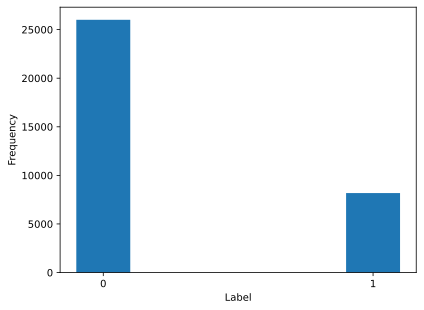

In [4]:
# class balance check 
plt.hist(y_train, bins=[-0.5, 0.5, 1.5], rwidth=0.2)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks([0, 1]); 

In [35]:
baseline_probabilities = baseline(2, len(test_dataset), train_loader)
y_baseline_pred = np.argmax(baseline_probabilities, axis=1)
base_acc = accuracy_score(y_test, y_baseline_pred)
print("Baseline accuracy is", round(base_acc, 3))

Baseline accuracy is 0.761


In [6]:
is_binary = True

for optimizer in optimizer_names:
    print(f"Optimizer: {optimizer}")
    
    # initialize arrays for metrics 
    metrics = {
        'train_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_acc': np.zeros((INIT_MAX, N_EPOCHS))
    }
    training_times = []
    
    # averaging over initializations 
    for i in range(INIT_MAX):
        # Set seeds
        torch.manual_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Initialize model
        if is_binary:
            loss_fun = nn.BCEWithLogitsLoss()
            model = Model1(X_train.shape[1])
        else: 
            loss_fun = nn.CrossEntropyLoss()
            model = Model2(X_train.shape[1])
        
        opt, train_loader = select_optimizer(model, train_dataset, optimizer)
        
        total_time = 0
        
        # need to set up closure for L-BFGS 
        if optimizer.lower() == "lbfgs":
            def closure():
                opt.zero_grad()
                outputs = model(X_train_tensor.to(device))
                loss = loss_fun(outputs, y_train_tensor.to(device))
                loss.backward()
                return loss
        
        # Training loop
        for epoch in range(N_EPOCHS):
            start_time = time.perf_counter()
            
            if optimizer.lower() == "lbfgs":
                train_loss, test_loss, test_accuracy = train_epoch_lbfgs(
                    model, opt, loss_fun, closure, X_test_tensor, y_test_tensor, device, is_binary
                )
            else:
                # None is for scheduler (see adam.ipynb)
                train_loss, test_loss, test_accuracy = train_epoch_sgd(
                    model, opt, loss_fun, train_loader, test_loader, device, None, is_binary
                )
            
            metrics['train_loss'][i, epoch] = train_loss
            metrics['test_loss'][i, epoch] = test_loss
            metrics['test_acc'][i, epoch] = test_accuracy
            
            epoch_time = time.perf_counter() - start_time
            total_time += epoch_time
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1} - Train: {train_loss:.4f}, Test: {test_loss:.4f}, Time: {epoch_time:.2f}s")
        
        training_times.append(total_time)
        print(f"Instance {i} - Total time: {total_time:.2f}s")
        print("--------------------------------")
    

    results_for_a9a[optimizer] = {
        "average_train_loss": metrics['train_loss'].mean(axis=0).tolist(),
        "average_test_loss": metrics['test_loss'].mean(axis=0).tolist(),
        "test_acc": metrics['test_acc'].mean(axis=0).tolist(),
        "training_time": float(np.mean(training_times))
    }


Optimizer: SGD
Epoch 1 - Train: 0.6237, Test: 0.5663, Time: 0.50s
Epoch 11 - Train: 0.4272, Test: 0.4226, Time: 0.44s
Epoch 21 - Train: 0.3901, Test: 0.3873, Time: 0.45s
Epoch 31 - Train: 0.3735, Test: 0.3712, Time: 0.49s
Instance 0 - Total time: 19.04s
--------------------------------
Epoch 1 - Train: 0.6320, Test: 0.5707, Time: 0.52s
Epoch 11 - Train: 0.4269, Test: 0.4227, Time: 0.51s
Epoch 21 - Train: 0.3904, Test: 0.3876, Time: 0.55s
Epoch 31 - Train: 0.3738, Test: 0.3716, Time: 0.47s
Instance 1 - Total time: 22.45s
--------------------------------
Epoch 1 - Train: 0.6289, Test: 0.5680, Time: 0.54s
Epoch 11 - Train: 0.4255, Test: 0.4215, Time: 0.65s
Epoch 21 - Train: 0.3892, Test: 0.3869, Time: 0.82s
Epoch 31 - Train: 0.3731, Test: 0.3712, Time: 0.49s
Instance 2 - Total time: 22.47s
--------------------------------
Optimizer: LBFGS
Epoch 1 - Train: 0.7195, Test: 0.3277, Time: 0.08s
Epoch 11 - Train: 0.3212, Test: 0.3297, Time: 0.03s
Epoch 21 - Train: 0.3212, Test: 0.3298, Time: 0.0

/Users/anastasiia_popova/Desktop/Work/Projects/Data Science/Adaptive Algorithms/code/Adaptive_Algorithms/adagradnorm.py:47: UserWarning: This overload of addcmul_ is deprecated:
	addcmul_(Number value, Tensor tensor1, Tensor tensor2)
Consider using one of the following signatures instead:
	addcmul_(Tensor tensor1, Tensor tensor2, *, Number value = 1) (Triggered internally at /private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_7918qdo__j/croot/libtorch_1744403106694/work/torch/csrc/utils/python_arg_parser.cpp:1642.)
  p.data.addcmul_(-1, adaptive_lr, grad)


Epoch 1 - Train: 0.4126, Test: 0.3697, Time: 0.61s
Epoch 11 - Train: 0.3309, Test: 0.3317, Time: 0.62s
Epoch 21 - Train: 0.3268, Test: 0.3287, Time: 0.58s
Epoch 31 - Train: 0.3254, Test: 0.3277, Time: 0.60s
Instance 0 - Total time: 24.95s
--------------------------------
Epoch 1 - Train: 0.4194, Test: 0.3733, Time: 0.62s
Epoch 11 - Train: 0.3306, Test: 0.3319, Time: 0.59s
Epoch 21 - Train: 0.3268, Test: 0.3288, Time: 0.61s
Epoch 31 - Train: 0.3252, Test: 0.3279, Time: 0.57s
Instance 1 - Total time: 27.51s
--------------------------------
Epoch 1 - Train: 0.4164, Test: 0.3718, Time: 0.60s
Epoch 11 - Train: 0.3309, Test: 0.3319, Time: 0.60s
Epoch 21 - Train: 0.3267, Test: 0.3289, Time: 0.65s
Epoch 31 - Train: 0.3253, Test: 0.3279, Time: 0.70s
Instance 2 - Total time: 28.41s
--------------------------------
Optimizer: RMSprop
Epoch 1 - Train: 0.4133, Test: 0.3581, Time: 0.71s
Epoch 11 - Train: 0.3231, Test: 0.3272, Time: 0.57s
Epoch 21 - Train: 0.3224, Test: 0.3281, Time: 0.61s
Epoch 31 -

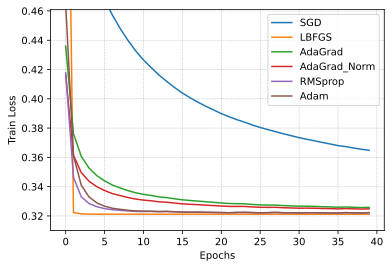

In [7]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    plt.plot(metrics["average_train_loss"], label=f'{method}')

plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.ylim(0.31, 0.461)
plt.legend()
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Train Loss vs Epochs A9a.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()

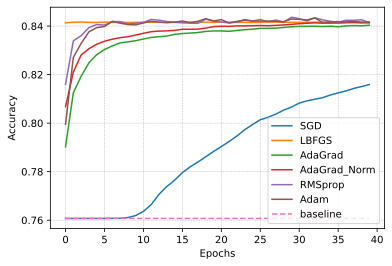

In [8]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    plt.plot(metrics["test_acc"], label=f'{method}')

plt.plot(np.arange(0,N_EPOCHS), [base_acc]*N_EPOCHS,'--', label=f'baseline')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs Epochs A9a.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()

### Logistic regression with the non-convex and smooth regularizer

In [10]:
is_binary = True

for optimizer in optimizer_names:
    print(f"Optimizer: {optimizer}")
    
    # initialize arrays for metrics 
    metrics = {
        'train_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_acc': np.zeros((INIT_MAX, N_EPOCHS))
    }
    training_times = []
    
    # averaging over initializations 
    for i in range(INIT_MAX):
        # Set seeds
        torch.manual_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Initialize model
        if is_binary:
            # custom loss
            model = Model1(X_train.shape[1])
            loss_fun = RLoss(model, is_binary=is_binary)
          
        else: 
            model = Model2(X_train.shape[1])
            loss_fun = RLoss(is_binary=is_binary)
           
        
        opt, train_loader = select_optimizer(model, train_dataset, optimizer)
        
        total_time = 0
        
        # need to set up closure for L-BFGS 
        if optimizer.lower() == "lbfgs":
            def closure():
                opt.zero_grad()
                outputs = model(X_train_tensor.to(device))
                loss = loss_fun(outputs, y_train_tensor.to(device))
                loss.backward()
                return loss
        
        # Training loop
        for epoch in range(N_EPOCHS):
            start_time = time.perf_counter()
            
            if optimizer.lower() == "lbfgs":
                train_loss, test_loss, test_accuracy = train_epoch_lbfgs(
                    model, opt, loss_fun, closure, X_test_tensor, y_test_tensor, device
                )
            else:
                train_loss, test_loss, test_accuracy = train_epoch_sgd(
                    model, opt, loss_fun, train_loader, test_loader, device, None, is_binary
                )
            
            metrics['train_loss'][i, epoch] = train_loss
            metrics['test_loss'][i, epoch] = test_loss
            metrics['test_acc'][i, epoch] = test_accuracy
            
            epoch_time = time.perf_counter() - start_time
            total_time += epoch_time
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1} - Train: {train_loss:.4f}, Test: {test_loss:.4f}, Time: {epoch_time:.2f}s")
        
        training_times.append(total_time)
        print(f"Instance {i} - Total time: {total_time:.2f}s")
        print("--------------------------------")
    

    results_for_a9a[f'{optimizer} custom loss'] = {
        "average_train_loss": metrics['train_loss'].mean(axis=0).tolist(),
        "average_test_loss": metrics['test_loss'].mean(axis=0).tolist(),
        "test_acc": metrics['test_acc'].mean(axis=0).tolist(),
        "training_time": float(np.mean(training_times))
    }


Optimizer: SGD
Epoch 1 - Train: 0.6274, Test: 0.5705, Time: 0.70s
Epoch 11 - Train: 0.4410, Test: 0.4370, Time: 0.64s
Epoch 21 - Train: 0.4126, Test: 0.4102, Time: 0.63s
Epoch 31 - Train: 0.4018, Test: 0.3999, Time: 0.64s
Instance 0 - Total time: 26.60s
--------------------------------
Epoch 1 - Train: 0.6354, Test: 0.5746, Time: 0.67s
Epoch 11 - Train: 0.4407, Test: 0.4371, Time: 0.65s
Epoch 21 - Train: 0.4129, Test: 0.4105, Time: 0.71s
Epoch 31 - Train: 0.4021, Test: 0.4003, Time: 0.79s
Instance 1 - Total time: 29.58s
--------------------------------
Epoch 1 - Train: 0.6325, Test: 0.5721, Time: 0.71s
Epoch 11 - Train: 0.4398, Test: 0.4363, Time: 0.70s
Epoch 21 - Train: 0.4121, Test: 0.4102, Time: 0.70s
Epoch 31 - Train: 0.4020, Test: 0.4002, Time: 0.71s
Instance 2 - Total time: 29.38s
--------------------------------
Optimizer: LBFGS
Epoch 1 - Train: 0.7229, Test: 0.3819, Time: 0.10s
Epoch 11 - Train: 0.3817, Test: 0.3819, Time: 0.01s
Epoch 21 - Train: 0.3817, Test: 0.3819, Time: 0.0

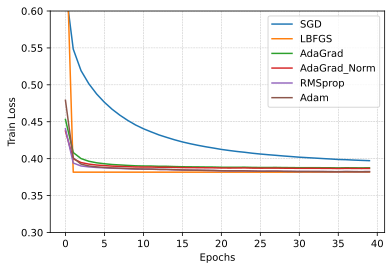

In [11]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    if "custom loss" in method: 
        plt.plot(metrics["average_train_loss"], label=f'{method.split()[0]}')

plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.ylim(0.3, 0.60)
plt.legend()
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Train Loss vs Epochs with Rloss A9a.png", dpi=fig.dpi,  bbox_inches='tight')
plt.show()

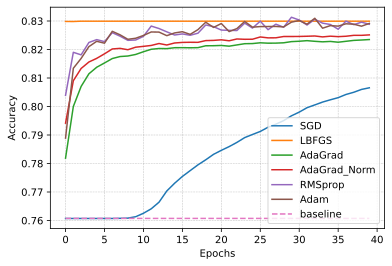

In [12]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    if "custom loss" in method: 
        plt.plot(metrics["test_acc"], label=f'{method.split()[0]}')

plt.plot(np.arange(0,N_EPOCHS), [base_acc]*N_EPOCHS,'--', label=f'baseline')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs Epochs with Rloss A9a.png", dpi=fig.dpi,  bbox_inches='tight')
plt.show()

In [13]:
df = pd.DataFrame({
    "Method": list(results_for_a9a.keys()),
    "ACC test": [results_for_a9a[method]["test_acc"][-1] for method in results_for_a9a],
    "Average training time": [results_for_a9a[method]["training_time"] for method in results_for_a9a]
})
df

,Method,ACC test,Average training time
0,SGD,0.815913,21.323469
1,LBFGS,0.841671,1.671972
2,AdaGrad,0.840340,23.036788
3,AdaGrad_Norm,0.841341,26.954804
4,RMSprop,0.841477,25.555458
5,Adam,0.841546,24.498480
6,SGD custom loss,0.806558,28.522308
7,LBFGS custom loss,0.829932,0.368244
8,AdaGrad custom loss,0.823487,30.658210
9,AdaGrad_Norm custom loss,0.825125,34.764359


### Effect of LR on accuracy

This is the most computationally expensive experiment (for the Covtype dataset it takes around 15 cpu hours). 

In [50]:
# almost the same code as above 
def run_lr_experiment(optimizer_name, learning_rates, X_train, y_train, X_test, y_test, train_loader, is_binary=True):

    results = {}
    acc_records = []
    time_records = [] 
    
    for lr in learning_rates:
        print(f"Optimizer: {optimizer_name}, Learning rate: {lr}")
        
        acc_list = []
        time_list = []
    
        for i in range(INIT_MAX):
            torch.manual_seed(SEED + i)
            np.random.seed(SEED + i)
            
            if is_binary:
                loss_fun =  nn.BCEWithLogitsLoss()
                model = Model1(X_train.shape[1])
                model = model.to(device)
            else:
                loss_fun =  nn.CrossEntropyLoss()
                model = Model2(X_train.shape[1])
                model = model.to(device)
                
            opt, train_loader = select_optimizer(
                model, 
                train_dataset,
                optimizer_name=optimizer_name,
                batch_type="mini",
                set_lr=True,
                learning_rate=lr
            )

            total_time = 0
            
            # need to set up closure for L-BFGS 
            if optimizer.lower() == "lbfgs":
                def closure():
                    opt.zero_grad()
                    outputs = model(X_train_tensor.to(device))
                    loss = loss_fun(outputs, y_train_tensor.to(device))
                    loss.backward()
                    return loss
            
            # Training loop
            for epoch in range(N_EPOCHS):
                start_time = time.perf_counter()
                
                if optimizer.lower() == "lbfgs":
                    train_loss, test_loss, test_accuracy = train_epoch_lbfgs(
                        model, opt, loss_fun, closure, X_test_tensor, y_test_tensor, device, is_binary
                    )
                else:
                    train_loss, test_loss, test_accuracy = train_epoch_sgd(
                        model, opt, loss_fun, train_loader, test_loader, device, None, is_binary
                    )    
    
                epoch_time = time.perf_counter() - start_time
                total_time += epoch_time
    
                training_times.append(total_time)

                if epoch == N_EPOCHS-1:
                    final_acc = test_accuracy
                    
                    acc_list.append(final_acc)
                    time_list.append(total_time)
                    print(f"Instance {i} - Total time: {total_time:.2f}s")
                    print("--------------------------------")
            
        acc_records.append( np.mean(acc_list) )
        time_records.append ( np.mean(time_list) )
            
    results[f'{optimizer_name} with different lr'] = {
            "learning rates" : learning_rates,
            "accuracy": acc_records,
            "training_time": time_records
        }
    
    return results

In [44]:
learning_rates = np.logspace(-4.5, 0, num=10)

for optimizer in optimizer_names: 
    res = run_lr_experiment(optimizer, learning_rates, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, train_loader, is_binary=True)
    results_for_a9a.update(res)     

Optimizer: SGD, Learning rate: 3.1622776601683795e-05
Instance 0 - Total time: 19.22s
--------------------------------
Instance 1 - Total time: 19.69s
--------------------------------
Instance 2 - Total time: 20.28s
--------------------------------
Optimizer: SGD, Learning rate: 0.0001
Instance 0 - Total time: 20.96s
--------------------------------
Instance 1 - Total time: 20.68s
--------------------------------
Instance 2 - Total time: 20.19s
--------------------------------
Optimizer: SGD, Learning rate: 0.00031622776601683794
Instance 0 - Total time: 19.88s
--------------------------------
Instance 1 - Total time: 19.69s
--------------------------------
Instance 2 - Total time: 20.00s
--------------------------------
Optimizer: SGD, Learning rate: 0.001
Instance 0 - Total time: 19.57s
--------------------------------
Instance 1 - Total time: 20.12s
--------------------------------
Instance 2 - Total time: 19.93s
--------------------------------
Optimizer: SGD, Learning rate: 0.0031

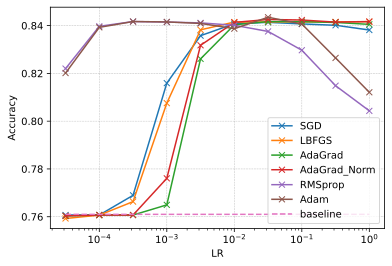

In [45]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_a9a.items():
    if "with different lr" in method: 
        plt.plot(metrics["learning rates"], metrics["accuracy"], '-x' , label=f'{method.split()[0]}')

plt.plot(learning_rates, [0.761]*len(learning_rates),'--', label=f'baseline')
plt.xlabel('LR')
plt.ylabel('Accuracy')
plt.xscale("log") 
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs LR A9a.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()

## Dataset 2 (Covtype) - multi-class classification

In [3]:
covtype = fetch_covtype()
X = covtype.data
y = torch.LongTensor(covtype.target-1)  # Convert to 0-6 range

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

X_train_scaled =  torch.FloatTensor(scaler.fit_transform(X_train[:,0:10])) #the rest are binary features
X_test_scaled = torch.FloatTensor(scaler.transform(X_test[:,0:10]) )

X_train_binary = torch.FloatTensor(X_train[:, 10:])
X_test_binary = torch.FloatTensor(X_test[:, 10:])

X_train_tensor = torch.cat((X_train_scaled, X_train_binary), dim=1)
X_test_tensor = torch.cat((X_test_scaled, X_test_binary), dim=1)

y_train_tensor = torch.clone(y_train) # for consistency 
y_test_tensor = torch.clone(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print("Train size: ", X_train.shape, "Test size:", X_test.shape)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

results_for_covtype = {}

Train size:  (406708, 54) Test size: (174304, 54)


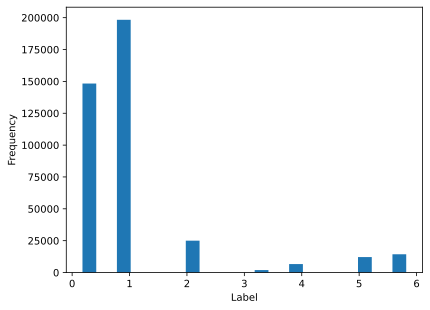

In [4]:
# class balance check 
plt.hist(y_train, rwidth=0.4)
plt.xlabel('Label')
plt.ylabel('Frequency');

In [5]:
baseline_probabilities = baseline(7, len(test_dataset), train_loader)
y_baseline_pred = np.argmax(baseline_probabilities, axis=1)
base_acc = accuracy_score(y_test, y_baseline_pred)
print("Baseline accuracy is", round(base_acc, 3))


Baseline accuracy is 0.488


In [6]:
is_binary = False 

for optimizer in optimizer_names:
    print(f"Optimizer: {optimizer}")
    
    # initialize arrays for metrics 
    metrics = {
        'train_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_acc': np.zeros((INIT_MAX, N_EPOCHS))
    }
    training_times = []
    
    # averaging over initializations 
    for i in range(INIT_MAX):
        # Set seeds
        torch.manual_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Initialize model
        if is_binary:
            loss_fun = nn.BCEWithLogitsLoss()
            model = Model1(X_train.shape[1])
        else: 
            loss_fun = nn.CrossEntropyLoss()
            model = Model2(X_train.shape[1])
        
        opt, train_loader = select_optimizer(model, train_dataset, optimizer)
        
        total_time = 0
        
        # need to set up closure for L-BFGS 
        if optimizer.lower() == "lbfgs":
            def closure():
                opt.zero_grad()
                outputs = model(X_train_tensor.to(device))
                loss = loss_fun(outputs, y_train_tensor.to(device))
                loss.backward()
                return loss
        
        # Training loop
        for epoch in range(N_EPOCHS):
            start_time = time.perf_counter()
            
            if optimizer.lower() == "lbfgs":
                train_loss, test_loss, test_accuracy = train_epoch_lbfgs(
                    model, opt, loss_fun, closure, X_test_tensor, y_test_tensor, device, is_binary
                )
            else:
                train_loss, test_loss, test_accuracy = train_epoch_sgd(
                    model, opt, loss_fun, train_loader, test_loader, device, None, is_binary
                )
            
            metrics['train_loss'][i, epoch] = train_loss
            metrics['test_loss'][i, epoch] = test_loss
            metrics['test_acc'][i, epoch] = test_accuracy
            
            epoch_time = time.perf_counter() - start_time
            total_time += epoch_time
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1} - Train: {train_loss:.4f}, Test: {test_loss:.4f}, Time: {epoch_time:.2f}s")
        
        training_times.append(total_time)
        print(f"Instance {i} - Total time: {total_time:.2f}s")
        print("--------------------------------")
    

    results_for_covtype[optimizer] = {
        "average_train_loss": metrics['train_loss'].mean(axis=0).tolist(),
        "average_test_loss": metrics['test_loss'].mean(axis=0).tolist(),
        "test_acc": metrics['test_acc'].mean(axis=0).tolist(),
        "training_time": float(np.mean(training_times))
    }


Optimizer: SGD
Epoch 1 - Train: 1.2503, Test: 0.9857, Time: 5.77s
Epoch 11 - Train: 0.7371, Test: 0.7354, Time: 5.87s
Epoch 21 - Train: 0.6993, Test: 0.6998, Time: 5.89s
Epoch 31 - Train: 0.6825, Test: 0.6835, Time: 5.95s
Instance 0 - Total time: 243.62s
--------------------------------
Epoch 1 - Train: 1.2698, Test: 0.9874, Time: 6.21s
Epoch 11 - Train: 0.7379, Test: 0.7361, Time: 6.34s
Epoch 21 - Train: 0.6996, Test: 0.6999, Time: 6.29s
Epoch 31 - Train: 0.6824, Test: 0.6834, Time: 6.54s
Instance 1 - Total time: 255.74s
--------------------------------
Epoch 1 - Train: 1.2453, Test: 0.9842, Time: 6.51s
Epoch 11 - Train: 0.7356, Test: 0.7340, Time: 6.63s
Epoch 21 - Train: 0.6982, Test: 0.6987, Time: 6.46s
Epoch 31 - Train: 0.6815, Test: 0.6826, Time: 6.55s
Instance 2 - Total time: 263.73s
--------------------------------
Optimizer: LBFGS
Epoch 1 - Train: 1.9261, Test: 0.6516, Time: 0.97s
Epoch 11 - Train: 0.6280, Test: 0.6305, Time: 0.90s
Epoch 21 - Train: 0.6279, Test: 0.6304, Time: 

/Users/anastasiia_popova/Desktop/Work/Projects/Data Science/Adaptive Algorithms/code/Adaptive_Algorithms/adagradnorm.py:47: UserWarning: This overload of addcmul_ is deprecated:
	addcmul_(Number value, Tensor tensor1, Tensor tensor2)
Consider using one of the following signatures instead:
	addcmul_(Tensor tensor1, Tensor tensor2, *, Number value = 1) (Triggered internally at /private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_7918qdo__j/croot/libtorch_1744403106694/work/torch/csrc/utils/python_arg_parser.cpp:1642.)
  p.data.addcmul_(-1, adaptive_lr, grad)


Epoch 1 - Train: 0.7998, Test: 0.7219, Time: 7.11s
Epoch 11 - Train: 0.6618, Test: 0.6631, Time: 7.43s
Epoch 21 - Train: 0.6541, Test: 0.6559, Time: 7.41s
Epoch 31 - Train: 0.6504, Test: 0.6523, Time: 7.56s
Instance 0 - Total time: 297.21s
--------------------------------
Epoch 1 - Train: 0.8072, Test: 0.7224, Time: 7.12s
Epoch 11 - Train: 0.6613, Test: 0.6627, Time: 7.47s
Epoch 21 - Train: 0.6538, Test: 0.6556, Time: 6.86s
Epoch 31 - Train: 0.6501, Test: 0.6520, Time: 7.45s
Instance 1 - Total time: 295.49s
--------------------------------
Epoch 1 - Train: 0.7964, Test: 0.7205, Time: 7.24s
Epoch 11 - Train: 0.6613, Test: 0.6627, Time: 7.50s
Epoch 21 - Train: 0.6538, Test: 0.6557, Time: 7.23s
Epoch 31 - Train: 0.6501, Test: 0.6521, Time: 7.62s
Instance 2 - Total time: 296.59s
--------------------------------
Optimizer: RMSprop
Epoch 1 - Train: 0.7225, Test: 0.6572, Time: 6.69s
Epoch 11 - Train: 0.6319, Test: 0.6347, Time: 7.02s
Epoch 21 - Train: 0.6305, Test: 0.6332, Time: 6.74s
Epoch 3

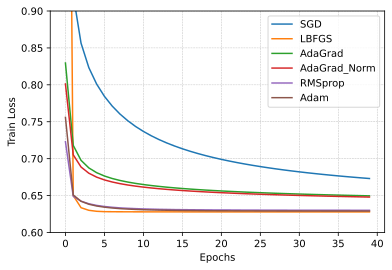

In [8]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    plt.plot(metrics["average_train_loss"], label=f'{method}')

plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.ylim(0.6, 0.9)
plt.legend()
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Train Loss vs Epochs Covtype.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()

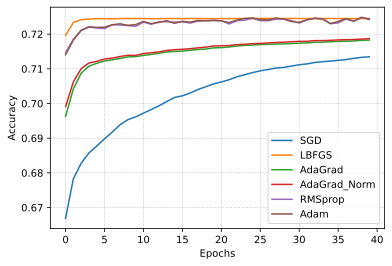

In [10]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    plt.plot(metrics["test_acc"], label=f'{method.split()[0]}')

#plt.plot(np.arange(0,N_EPOCHS), [base_acc]*N_EPOCHS,'--', label=f'baseline')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs Epochs Covtype.png", dpi=fig.dpi,  bbox_inches='tight')
plt.show()

### Logistic regression with the non-convex and smooth regularizer

In [26]:
is_binary = False

for optimizer in optimizer_names:
    print(f"Optimizer: {optimizer}")
    
    # initialize arrays for metrics 
    metrics = {
        'train_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_loss': np.zeros((INIT_MAX, N_EPOCHS)),
        'test_acc': np.zeros((INIT_MAX, N_EPOCHS))
    }
    training_times = []
    
    # averaging over initializations 
    for i in range(INIT_MAX):
        # Set seeds
        torch.manual_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Initialize model
        if is_binary:
            # custom loss
            model = Model1(X_train.shape[1])
            loss_fun = RLoss(model, is_binary=is_binary)
        else: 
            model = Model2(X_train.shape[1])
            loss_fun = RLoss(model, is_binary=is_binary)
        
        opt, train_loader = select_optimizer(model, train_dataset, optimizer)
        
        total_time = 0
        
        # need to set up closure for L-BFGS 
        if optimizer.lower() == "lbfgs":
            def closure():
                opt.zero_grad()
                outputs = model(X_train_tensor.to(device))
                loss = loss_fun(outputs, y_train_tensor.to(device))
                loss.backward()
                return loss
        
        # Training loop
        for epoch in range(N_EPOCHS):
            start_time = time.perf_counter()
             
            if optimizer.lower() == "lbfgs":
                train_loss, test_loss, test_accuracy = train_epoch_lbfgs(
                    model, opt, loss_fun, closure, X_test_tensor, y_test_tensor, device, is_binary=False
                )
            else:
                train_loss, test_loss, test_accuracy = train_epoch_sgd(
                    model, opt, loss_fun, train_loader, test_loader, device, None, is_binary
                )
            
            
            metrics['train_loss'][i, epoch] = train_loss
            metrics['test_loss'][i, epoch] = test_loss
            metrics['test_acc'][i, epoch] = test_accuracy
            
            epoch_time = time.perf_counter() - start_time
            total_time += epoch_time
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch+1} - Train: {train_loss:.4f}, Test: {test_loss:.4f}, Time: {epoch_time:.2f}s")
        
        training_times.append(total_time)
        print(f"Instance {i} - Total time: {total_time:.2f}s")
        print("--------------------------------")
    

    results_for_covtype[f'{optimizer} custom loss'] = {
        "average_train_loss": metrics['train_loss'].mean(axis=0).tolist(),
        "average_test_loss": metrics['test_loss'].mean(axis=0).tolist(),
        "test_acc": metrics['test_acc'].mean(axis=0).tolist(),
        "training_time": float(np.mean(training_times))
    }

Optimizer: SGD
Epoch 1 - Train: 1.2966, Test: 1.0510, Time: 9.77s
Epoch 11 - Train: 0.8620, Test: 0.8610, Time: 9.08s
Epoch 21 - Train: 0.8338, Test: 0.8341, Time: 8.93s
Epoch 31 - Train: 0.8194, Test: 0.8201, Time: 9.07s
Instance 0 - Total time: 364.54s
--------------------------------
Epoch 1 - Train: 1.3146, Test: 1.0511, Time: 9.20s
Epoch 11 - Train: 0.8605, Test: 0.8595, Time: 9.10s
Epoch 21 - Train: 0.8324, Test: 0.8327, Time: 9.14s
Epoch 31 - Train: 0.8184, Test: 0.8191, Time: 9.04s
Instance 1 - Total time: 366.27s
--------------------------------
Epoch 1 - Train: 1.2899, Test: 1.0480, Time: 9.14s
Epoch 11 - Train: 0.8595, Test: 0.8586, Time: 8.87s
Epoch 21 - Train: 0.8321, Test: 0.8324, Time: 9.19s
Epoch 31 - Train: 0.8183, Test: 0.8190, Time: 9.27s
Instance 2 - Total time: 367.42s
--------------------------------
Optimizer: LBFGS
Epoch 1 - Train: 1.9504, Test: 0.8032, Time: 0.83s
Epoch 11 - Train: 0.7814, Test: 0.7826, Time: 0.06s
Epoch 21 - Train: 0.7814, Test: 0.7826, Time: 

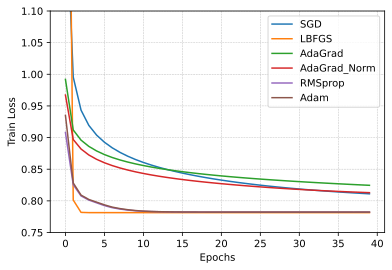

In [31]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    if "custom loss" in method: 
        plt.plot(metrics["average_train_loss"], label=f'{method.split()[0]}')

plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.ylim(0.75, 1.1)
# plt.yscale('log')
plt.legend()
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Train Loss vs Epochs with Rloss Covtype.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()

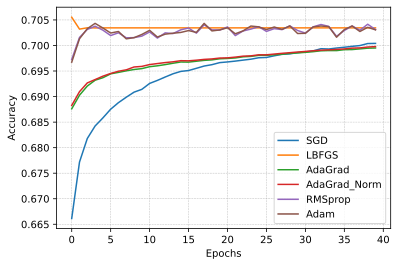

In [33]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    if "custom loss" in method: 
        plt.plot(metrics["test_acc"], label=f'{method.split()[0]}')

#plt.plot(np.arange(0,N_EPOCHS), [base_acc]*N_EPOCHS,'--', label=f'baseline')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs Epochs with Rloss Covtype.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()

In [29]:
df = pd.DataFrame({
    "Method": list(results_for_covtype.keys()),
    "ACC test": [results_for_covtype[method]["test_acc"][-1] for method in results_for_covtype],
    "Average training time": [results_for_covtype[method]["training_time"] for method in results_for_covtype]
})
df

,Method,ACC test,Average training time
0,SGD,0.713473,253.278158
1,LBFGS,0.724495,24.373028
2,AdaGrad,0.718297,277.574059
3,AdaGrad_Norm,0.718696,290.770203
4,RMSprop,0.724215,280.740660
5,Adam,0.724371,290.264276
6,SGD custom loss,0.700408,366.075519
7,LBFGS custom loss,0.703445,4.395935
8,AdaGrad custom loss,0.699507,381.615817
9,AdaGrad_Norm custom loss,0.699783,394.665490


### Effect of LR on accuracy

In [53]:
learning_rates = np.logspace(-4.5, 0, num=10)

for optimizer in optimizer_names: 
    res = run_lr_experiment(optimizer, learning_rates, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, train_loader, is_binary=False)
    results_for_covtype.update(res) 

Optimizer: SGD, Learning rate: 3.1622776601683795e-05
Instance 0 - Total time: 262.48s
--------------------------------
Instance 1 - Total time: 269.38s
--------------------------------
Instance 2 - Total time: 275.77s
--------------------------------
Optimizer: SGD, Learning rate: 0.0001
Instance 0 - Total time: 287.33s
--------------------------------
Instance 1 - Total time: 291.32s
--------------------------------
Instance 2 - Total time: 269.20s
--------------------------------
Optimizer: SGD, Learning rate: 0.00031622776601683794
Instance 0 - Total time: 299.54s
--------------------------------
Instance 1 - Total time: 274.04s
--------------------------------
Instance 2 - Total time: 270.76s
--------------------------------
Optimizer: SGD, Learning rate: 0.001
Instance 0 - Total time: 276.28s
--------------------------------
Instance 1 - Total time: 256.17s
--------------------------------
Instance 2 - Total time: 252.44s
--------------------------------
Optimizer: SGD, Learning 

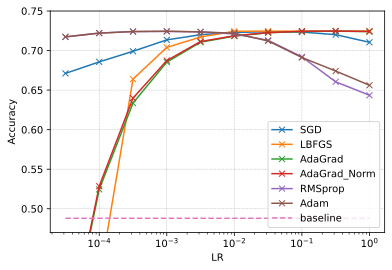

In [54]:
fig = plt.figure(figsize=(6, 4))
for method, metrics in results_for_covtype.items():
    if "with different lr" in method: 
        plt.plot(metrics["learning rates"], metrics["accuracy"], '-x',label=f'{method.split()[0]}')

plt.plot(learning_rates, [0.488]*len(learning_rates),'--', label=f'baseline')
plt.xlabel('LR')
plt.ylabel('Accuracy')
plt.ylim(0.47,0.75)
plt.xscale("log") 
plt.legend(loc='lower right')
plt.grid(linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig("plots/Test ACC vs LR Covtype.png", dpi=fig.dpi, bbox_inches='tight')
plt.show()